In [3]:
# Package imports
import numpy as np                                  # "Scientific computing"
import scipy.stats as stats                         # Statistical tests

import pandas as pd                                 # Dataframe
import matplotlib.pyplot as plt                     # Basic visualisation
from statsmodels.graphics.mosaicplot import mosaic  # Mosaic plot
import seaborn as sns                               # Advanced dataviz

Zoek naar woorden als: "Is er een verschil tussen...", "Is de ene groep groter/sneller/beter dan de andere?", of "Is de verandering significant?".

Als de vraag vergelijkt of gemiddelden van groepen van elkaar verschillen, dan kom je bijna altijd uit bij een t-test.

Het doel van de t-test: Je vergelijkt altijd een kwantitatieve variabele (getallen, zoals Score, Tijd, Duur, Rating) over twee groepen.

Hoe zie je dit?

    Heb je een kolom met getallen (bijv. Score) en een kolom die de groep aangeeft (bijv. Sessie of Exerciser)? -> t-test

    Heb je twee kolommen met getallen (bijv. Local_tijd en Chain_tijd) die samen één rij vormen? -> t-test

### Het verschil tussen ttest_ind en ttest_rel

Het kiezen van de juiste t-test is afhankelijk van hoe de data verzameld is en of er een afhankelijkheid bestaat tussen de groepen.

#### 1. stats.ttest_ind (Independent T-test)
Gebruik dit wanneer je **twee onafhankelijke groepen** vergelijkt. De deelnemers in de ene groep hebben geen relatie met de deelnemers in de andere groep.

* **Wanneer:** De steekproeven zijn onafhankelijk van elkaar.
* **Voorbeeld:** Het vergelijken van de productiviteit van medewerkers die sporten versus medewerkers die niet sporten.
* **Doel:** Het vergelijken van het gemiddelde van twee afzonderlijke populaties.

#### 2. stats.ttest_rel (Paired T-test)
Gebruik dit wanneer je **twee afhankelijke groepen** vergelijkt (gepaarde waarnemingen). Dit is vaak het geval wanneer dezelfde groep mensen op twee verschillende momenten wordt gemeten.

* **Wanneer:** De data bestaat uit paren van waarnemingen (bijv. een voor- en nameting bij dezelfde personen).
* **Voorbeeld:** Het vergelijken van de productiviteit van *dezelfde* werknemers vóór en na de installatie van fitnessapparatuur.
* **Doel:** Het vergelijken van de verandering binnen dezelfde groep/populatie.

---

### Visueel overzicht

| Kenmerk | `ttest_ind` (Independent) | `ttest_rel` (Related/Paired) |
| :--- | :--- | :--- |
| **Relatie** | Geen relatie tussen groepen | Sterke relatie (zelfde subjecten) |
| **Data** | Groep A en B zijn verschillend | Pre-test en Post-test van dezelfde groep |
| **Doel** | Verschil tussen twee populaties | Verschil binnen dezelfde populatie |

---

### Samenvattend:
Vraag jezelf af: **"Zijn de waarnemingen in de ene groep gekoppeld aan specifieke waarnemingen in de andere groep?"**

* **Ja (bijv. voor/na metingen):** Gebruik `ttest_rel`.
* **Nee (twee willekeurige, losse groepen):** Gebruik `ttest_ind`.

## Question 1

The data frame below shows the evolution of the average duration of a first marriage in Belgium, since 2015 by type of marriage (male-female / female-female / male-male) (Source: StatBel). Can we say that a man-man marriage lasts significantly longer than a woman-woman marriage?  
Make a plot!



In [6]:
divorces = pd.DataFrame(data={
    'year': [2015,2016,2017,2018,2019,2020,2021,2022,2023],
    'm_f': [16.7, 16.9, 16.9, 16.7, 16.7, 16.4, 16.6, 16.7, 16.1],
    'f_f': [5.5, 6.4, 6.3, 7.4, 6.7, 6.7, 7.0, 7.8, 8.0],
    'm_m': [6.0, 6.3, 6.9, 7.4, 7.4, 8.0, 8.2, 8.2, 8.5]
}).set_index('year')
divorces.head()
divorces.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 2015 to 2023
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   m_f     9 non-null      float64
 1   f_f     9 non-null      float64
 2   m_m     9 non-null      float64
dtypes: float64(3)
memory usage: 348.0 bytes


In [3]:
t_stat, p_val = stats.ttest_ind(divorces['m_m'], 
                                divorces['f_f'], 
                                alternative='greater')

print(f"T-statistiek: {t_stat:.3f}")
print(f"P-waarde: {p_val:.4f}")

T-statistiek: 1.438
P-waarde: 0.0848


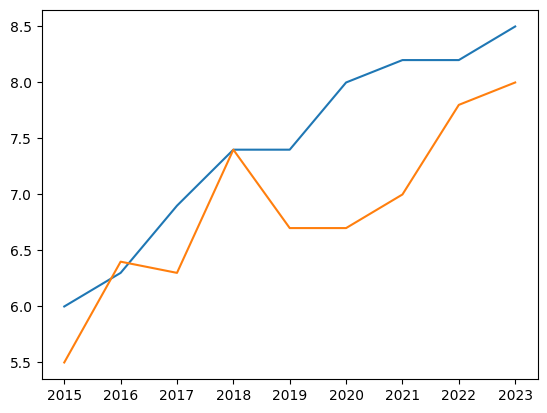

In [4]:
plt.plot(divorces.index, divorces['m_m'])
plt.plot(divorces.index, divorces['f_f'])
plt.show()

## Question 2

The data frame below shows the evolution of the average duration of a first and a subsequent marriage in Belgium since 2015 (Source: StatBel). Can we say that a first marriage lasts significantly longer than a subsequent marriage? Make a plot!


In [4]:
divorces = pd.DataFrame(data={
    'year': [2015,2016,2017,2018,2019,2020,2021,2022,2023],
    'first_marriage': [16.7, 16.9, 16.9, 16.7, 16.7, 16.4, 16.6, 16.7, 16.1],
    'subsequent_marriage': [10.5, 11.0, 11.2, 11.3, 11.3, 11.4, 11.5, 11.9, 11.8]
}).set_index('year')
divorces.head()
divorces.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 2015 to 2023
Data columns (total 2 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   first_marriage       9 non-null      float64
 1   subsequent_marriage  9 non-null      float64
dtypes: float64(2)
memory usage: 276.0 bytes


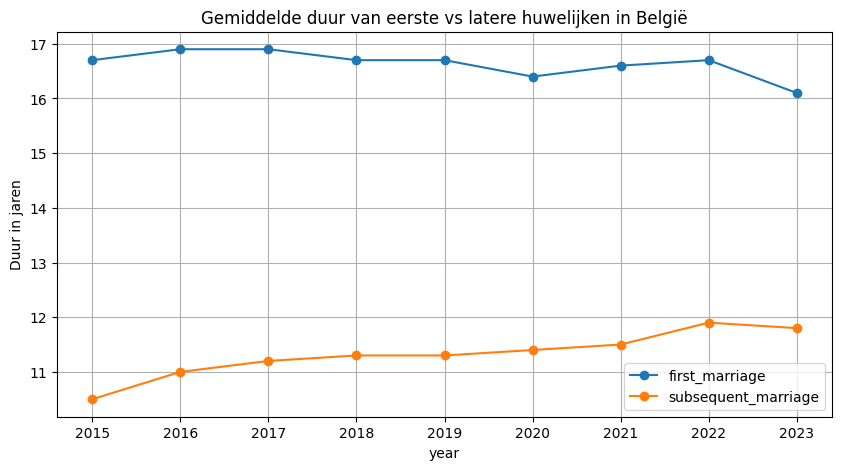

In [10]:
divorces.plot(kind='line', marker='o', figsize=(10, 5))
plt.title('Gemiddelde duur van eerste vs latere huwelijken in België')
plt.ylabel('Duur in jaren')
plt.grid(True)
plt.show()

In [11]:
stats.ttest_rel(divorces['first_marriage'], divorces['subsequent_marriage'])
print(f"T-statistic: {t_stat:.4f}")
print(f"p-value: {p_val:.10f}")

if p_val < 0.05:
    print("Conclusie: Het verschil is statistisch significant.")
else:
    print("Conclusie: Er is geen significant verschil gevonden.")

T-statistic: 1.4380
p-value: 0.0848463474
Conclusie: Er is geen significant verschil gevonden.


## Question 3
A local pizzeria claims that they can deliver pizza faster than a local branch of a large chain. To verify this, you ordered pizza from both of them 10 times. Below are the times (in minutes) they took. Can the local pizzeria indeed deliver pizzas significantly faster than the big player? Make a plot.



In [5]:
dfpizzas = pd.DataFrame(data= {'local': [16.8, 11.7, 15.6, 16.7, 17.5, 18.1, 14.1, 21.8, 13.9, 20.8],
                               'chain': [22.0, 15.2, 18.7, 15.6, 20.8, 19.5, 17.0, 19.5, 16.5, 24.0]})
dfpizzas.head()
dfpizzas.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   local   10 non-null     float64
 1   chain   10 non-null     float64
dtypes: float64(2)
memory usage: 292.0 bytes


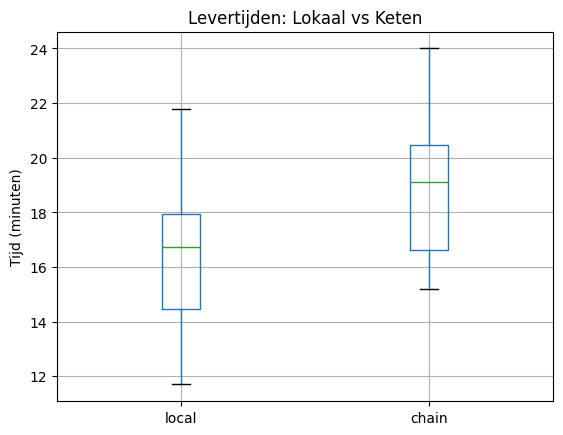

In [17]:
dfpizzas.boxplot()
plt.title('Levertijden: Lokaal vs Keten')
plt.ylabel('Tijd (minuten)')
plt.show()

In [16]:
t, p = stats.ttest_ind(dfpizzas['local'], dfpizzas['chain'],alternative='less')
print(p)
if p < 0.05:
    print("Conclusie: Het verschil is statistisch significant.")
else:
    print("Conclusie: Er is geen significant verschil gevonden.")

0.059802771662321265
Conclusie: Er is geen significant verschil gevonden.


In [18]:
dfpizzas.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   local   10 non-null     float64
 1   chain   10 non-null     float64
dtypes: float64(2)
memory usage: 292.0 bytes
